In [1]:
import pickle

import scanpy as sc

import scvi
from benchmark_utils import (
    add_cell_types_grouped,
    load_dlbcl_bulk,
    create_dirichlet_pseudobulk_dataset,
    create_anndata_pseudobulk,
    create_latent_signature,
)

from benchmark_utils.latent_signature_utils import create_latent_signature

from constants import (
    N_GENES,
    TRAINING_CELL_TYPE_GROUP,
)

/home/owkin/deepdeconv-fork/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/owkin/deepdeconv-fork/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
model_path = "project/mixupvi_highest_r2_genes_DLBCL_2nd_gran"

with open(f"project/highest_r2_genes_DLBCL_2nd_gran.pkl", "rb") as f:
    filtered_genes = pickle.load(f)

In [3]:
dlbcl_data = sc.read("/home/owkin/project/data/dlbcl_data/processed/dlbcl_sc_processed_v2.h5ad")

cell_type = f"cell_types_grouped_{TRAINING_CELL_TYPE_GROUP}"

dlbcl_data, train_test_index = add_cell_types_grouped(dlbcl_data, TRAINING_CELL_TYPE_GROUP)

dlbcl_data.obs["cell_types_grouped"] = dlbcl_data.obs[cell_type] #THIS SHOULD NOT BE DONE  

dlbcl_adata_train = dlbcl_data[train_test_index["Train index"]]
dlbcl_adata_test = dlbcl_data[train_test_index["Test index"]]

dlbcl_adata_train = dlbcl_adata_train[:, filtered_genes]

In [4]:
dlbcl_adata_train

View of AnnData object with n_obs × n_vars = 97627 × 2000
    obs: 'orig.ident', 'percent_reads_mt', 'percent_reads_ribo', 'percent_reads_hb', 'doublet_score_scdblfinder', 'doublet_predicted_scdblfinder', 'seurat_clusters', 'seurat_clusters_res_0.1', 'seurat_clusters_res_0.2', 'seurat_clusters_res_0.4', 'seurat_clusters_res_0.6', 'seurat_clusters_res_0.8', 'seurat_clusters_res_1', 'seurat_clusters_res_2', 'origin', '_scvi_batch', '_scvi_labels', 'scanvi_score', 'celltype_level1_scanvi', 'celltype_level2_scanvi', 'celltype_level3_scanvi', 'celltype_level4_scanvi', 'celltype_level_custom1_scanvi', 'SCT_snn_res.0.4', 'SCT_snn_res.2', 'seurat_clusters_heterogeneity', 'seurat_clusters_res_1.5', 'seurat_clusters_res_2.5', 'seurat_clusters_res_3', 'seurat_clusters_res_3.5', 'seurat_clusters_res_4', 'cell_types_grouped_DLBCL_2nd_level_granularity', 'cell_types_grouped'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'celltype_annotation_reference', 'log1p', 'neighbors', 'scanv

In [5]:
import numpy as np

# Sample a small representative dataset with equal numbers of cells from each cell type group
n_cells_per_type = 40 # Number of cells to sample from each type
cell_types = dlbcl_adata_train.obs[cell_type].unique()

sampled_indices = []
for ct in cell_types:
    ct_indices = dlbcl_adata_train.obs[dlbcl_adata_train.obs[cell_type] == ct].index
    if len(ct_indices) >= n_cells_per_type:
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=False)
    else:
        # If not enough cells, sample with replacement
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=True)
    sampled_indices.extend(sampled)

small_sc_dataset = dlbcl_adata_train[sampled_indices].copy()

In [6]:
small_sc_dataset

AnnData object with n_obs × n_vars = 360 × 2000
    obs: 'orig.ident', 'percent_reads_mt', 'percent_reads_ribo', 'percent_reads_hb', 'doublet_score_scdblfinder', 'doublet_predicted_scdblfinder', 'seurat_clusters', 'seurat_clusters_res_0.1', 'seurat_clusters_res_0.2', 'seurat_clusters_res_0.4', 'seurat_clusters_res_0.6', 'seurat_clusters_res_0.8', 'seurat_clusters_res_1', 'seurat_clusters_res_2', 'origin', '_scvi_batch', '_scvi_labels', 'scanvi_score', 'celltype_level1_scanvi', 'celltype_level2_scanvi', 'celltype_level3_scanvi', 'celltype_level4_scanvi', 'celltype_level_custom1_scanvi', 'SCT_snn_res.0.4', 'SCT_snn_res.2', 'seurat_clusters_heterogeneity', 'seurat_clusters_res_1.5', 'seurat_clusters_res_2.5', 'seurat_clusters_res_3', 'seurat_clusters_res_3.5', 'seurat_clusters_res_4', 'cell_types_grouped_DLBCL_2nd_level_granularity', 'cell_types_grouped'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'celltype_annotation_reference', 'log1p', 'neighbors', 'scanvi_probs', 

In [7]:
bulk_data = load_dlbcl_bulk()
bulk_data["dataset"] = bulk_data["dataset"].loc[filtered_genes]
obs_names = bulk_data["dataset"].columns
bulk_data["dataset"] = create_anndata_pseudobulk(
                adata_obs=dlbcl_adata_train.obs,
                adata_var_names=filtered_genes,
                x=bulk_data["dataset"].T.values,
            )

bulk_data["dataset"]

2025-06-23 14:14:52.718 | WARNING  | benchmark_utils.load_dataset_utils:load_dlbcl_bulk:122 - The ground truth data for the Bulk DLBCL dataset is just a dummy dataset, not a real one.


AnnData object with n_obs × n_vars = 23 × 2000
    obs: 'orig.ident', 'percent_reads_mt', 'percent_reads_ribo', 'percent_reads_hb', 'doublet_score_scdblfinder', 'doublet_predicted_scdblfinder', 'seurat_clusters', 'seurat_clusters_res_0.1', 'seurat_clusters_res_0.2', 'seurat_clusters_res_0.4', 'seurat_clusters_res_0.6', 'seurat_clusters_res_0.8', 'seurat_clusters_res_1', 'seurat_clusters_res_2', 'origin', '_scvi_batch', '_scvi_labels', 'scanvi_score', 'celltype_level1_scanvi', 'celltype_level2_scanvi', 'celltype_level3_scanvi', 'celltype_level4_scanvi', 'celltype_level_custom1_scanvi', 'SCT_snn_res.0.4', 'SCT_snn_res.2', 'seurat_clusters_heterogeneity', 'seurat_clusters_res_1.5', 'seurat_clusters_res_2.5', 'seurat_clusters_res_3', 'seurat_clusters_res_3.5', 'seurat_clusters_res_4', 'cell_types_grouped_DLBCL_2nd_level_granularity', 'cell_types_grouped'
    layers: 'counts'

In [8]:
pseudobulks_data_mean = create_dirichlet_pseudobulk_dataset(dlbcl_adata_train, cell_type_group=cell_type, n_cells=256, n_sample = 100, aggregation_method="mean")
pseudobulks_data_mean["adata_pseudobulk_test_counts"]

AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'orig.ident', 'percent_reads_mt', 'percent_reads_ribo', 'percent_reads_hb', 'doublet_score_scdblfinder', 'doublet_predicted_scdblfinder', 'seurat_clusters', 'seurat_clusters_res_0.1', 'seurat_clusters_res_0.2', 'seurat_clusters_res_0.4', 'seurat_clusters_res_0.6', 'seurat_clusters_res_0.8', 'seurat_clusters_res_1', 'seurat_clusters_res_2', 'origin', '_scvi_batch', '_scvi_labels', 'scanvi_score', 'celltype_level1_scanvi', 'celltype_level2_scanvi', 'celltype_level3_scanvi', 'celltype_level4_scanvi', 'celltype_level_custom1_scanvi', 'SCT_snn_res.0.4', 'SCT_snn_res.2', 'seurat_clusters_heterogeneity', 'seurat_clusters_res_1.5', 'seurat_clusters_res_2.5', 'seurat_clusters_res_3', 'seurat_clusters_res_3.5', 'seurat_clusters_res_4', 'cell_types_grouped_DLBCL_2nd_level_granularity', 'cell_types_grouped'
    layers: 'counts'

In [9]:
mixup_model = scvi.model.MixUpVI.load(model_path, dlbcl_adata_train.copy())

INFO     File project/mixupvi_highest_r2_genes_DLBCL_2nd_gran/model.pt already downloaded                          


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [10]:
latent_sc_mixup = mixup_model.get_latent_representation(small_sc_dataset)
sc_cell_type = small_sc_dataset.obs[cell_type]

latent_bulk_mixup = mixup_model.get_latent_representation(bulk_data["dataset"])
latent_pseudobulk_mean_mixup = mixup_model.get_latent_representation(pseudobulks_data_mean["adata_pseudobulk_test_counts"])

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [11]:
latent_signature_data_mean_mixup = create_latent_signature(adata=dlbcl_adata_train, model=mixup_model, use_mixupvi=False, average_all_cells=True)
latent_signature_mean_mixup = latent_signature_data_mean_mixup.X

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

In [12]:
latent_signature_cell_type_mean_mixup = latent_signature_data_mean_mixup.obs["cell type"]


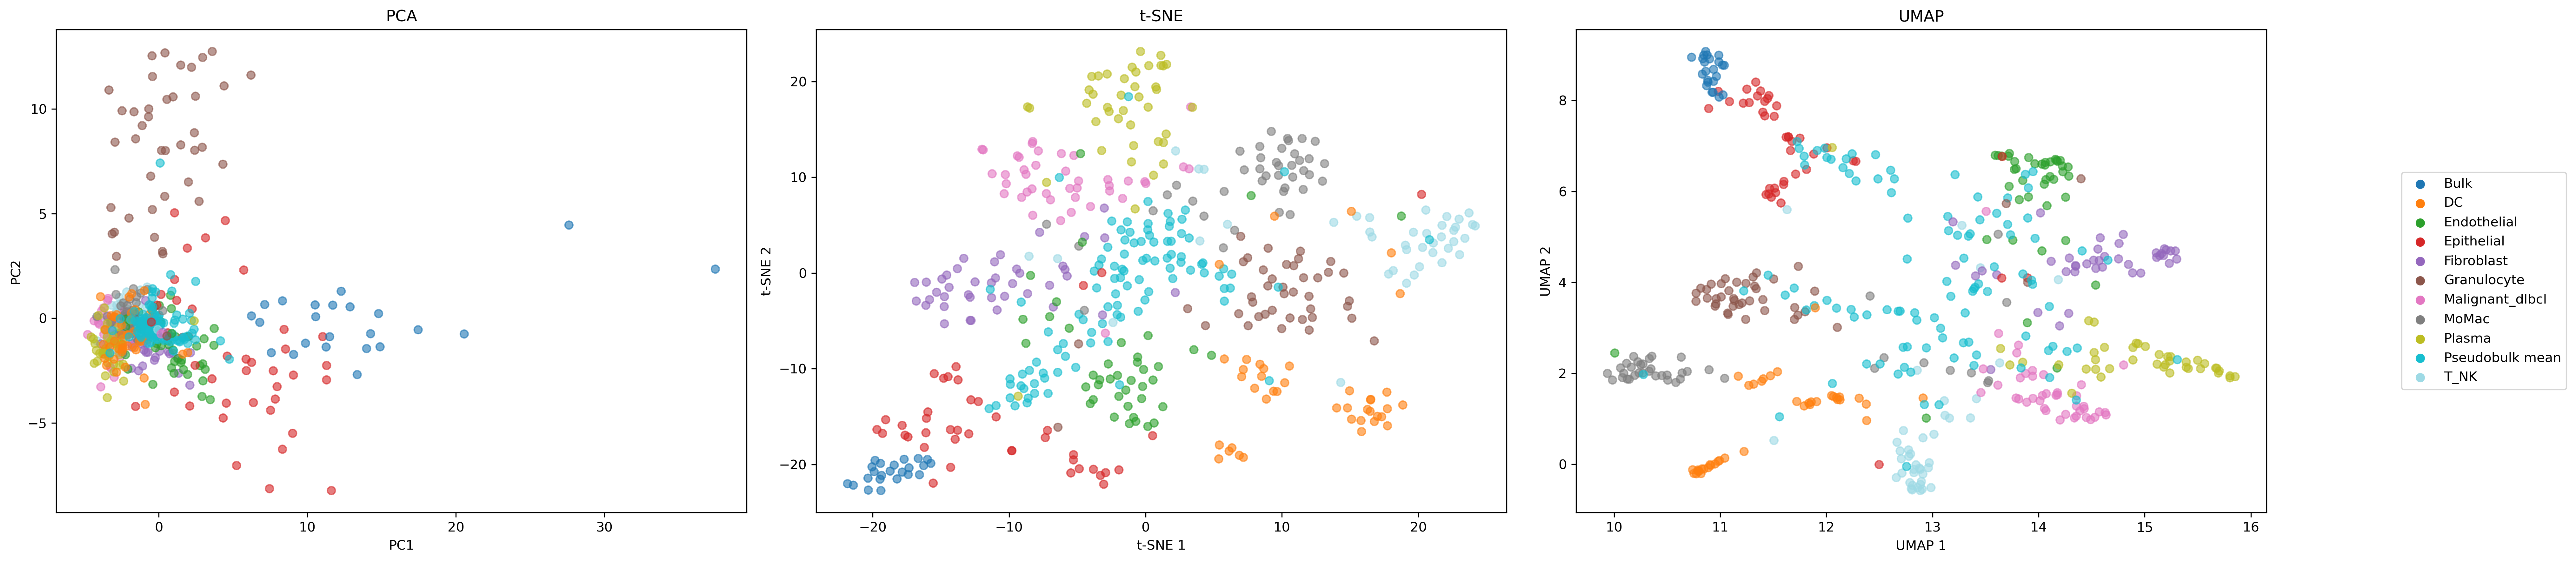

In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt

# Concatenate latent representations for MixupVI
all_latent_mixup = np.concatenate([
    latent_sc_mixup,
    latent_signature_mean_mixup,
    latent_pseudobulk_mean_mixup,
    latent_bulk_mixup,
])

labels = np.concatenate([
    sc_cell_type,
    np.array(['Pseudobulk mean']*len(latent_pseudobulk_mean_mixup)),
    latent_signature_cell_type_mean_mixup,
    np.array(['Bulk']*len(latent_bulk_mixup)),
])

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

latent_2d_pca_mixup = pca.fit_transform(all_latent_mixup)
latent_2d_tsne_mixup = tsne.fit_transform(all_latent_mixup)
latent_2d_umap_mixup = umap.fit_transform(all_latent_mixup)

# Create a figure with three subplots side by side
plt.figure(figsize=(24, 6), dpi=300)

# Create a color map for unique labels
unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
color_dict = dict(zip(unique_labels, colors))
point_colors = np.array([color_dict[label] for label in labels])

# Plot PCA
plt.subplot(131)
plt.scatter(latent_2d_pca_mixup[:, 0], latent_2d_pca_mixup[:, 1], c=point_colors, alpha=0.6)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Plot t-SNE
plt.subplot(132)
plt.scatter(latent_2d_tsne_mixup[:, 0], latent_2d_tsne_mixup[:, 1], c=point_colors, alpha=0.6)
plt.title('t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Plot UMAP
plt.subplot(133)
plt.scatter(latent_2d_umap_mixup[:, 0], latent_2d_umap_mixup[:, 1], c=point_colors, alpha=0.6)
plt.title('UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Add legend
legend_elements = [plt.scatter([], [], c=[color_dict[label]], label=label) for label in unique_labels]
plt.figlegend(handles=legend_elements, labels=list(unique_labels), bbox_to_anchor=(1.05, 0.5), loc='center left')

plt.tight_layout()
plt.show()